# Gradient Boosting - Clasificación de Gravedad en Accidentes de Tránsito

> **Dataset:** `DataSet_Accidentes_500.xlsx` — 500 registros, los cuales fueron aleatorizados.
> **Objetivo:** Predecir si un accidente resulta en **Muertos (1)** o **Heridos (0)**  
> **Mejoras v2:**
> - Grid de hiperparámetros ampliado con `min_samples_leaf`

## 1. Librerías y configuraciones

In [25]:
#-----------------------------LIBRERÍAS NECESARIAS---------------------------------------
import pandas as pd
import numpy as np
import joblib, os

# Modelado
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score, recall_score, precision_score
)

# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print('Librerías cargadas ✓')

Librerías cargadas ✓


## 2. Parámetros globales

In [26]:
#----------------------PARÁMETROS INICIALES Y RUTAS DE REPOSITORIOS------------------------

GITHUB_BASE_URL           = 'https://raw.githubusercontent.com/yorbisUdeA/udea/main/'
DATASET_FILE_NAME         = 'DataSet_Accidentes.xlsx'
UTILS_FILE_NAME           = 'funciones.py'
DATASETS_PATH             = 'datasets/'
MODELS_CLASIFICACION_PATH = 'modelos/clasificacion/'
MODELS_SCALER_PATH        = 'modelos/scaler/'
DATASET_FILE_NAME         = 'DataSet_Accidentes_500.xlsx'
local_dataset_path        = os.path.join('/content/', DATASET_FILE_NAME)

for path in [DATASETS_PATH, MODELS_CLASIFICACION_PATH, MODELS_SCALER_PATH]:
    os.makedirs(path, exist_ok=True)

TARGET         = 'Gravedad'
CLASE_POSITIVA = 'Muertos'
CLASE_NEGATIVA = 'Heridos'
RANDOM_STATE   = 123

print('Parámetros configurados ✓')

Parámetros configurados ✓


## 3. Carga del dataset

Once your Drive is mounted, you can locate the path to your `DataSet_Accidentes_500.xlsx` file. For example, if it's in a folder called 'MyData' in your Drive, the path might be `/content/drive/MyDrive/MyData/DataSet_Accidentes_500.xlsx`.

Then, you will need to **manually update the `local_dataset_path` variable in cell `wuRkFfy7oJrY`** to this new Drive path. After that, re-run cell `HBT2fy6poJrZ` to load the dataset.

In [27]:
#-----------------SE CARGA EL DATAFRAME---------------------------------
DATASET_PATH = r'C:\\Users\\Santiago\\Desktop\\Esp\\DataSet_Accidentes_500_v2.xlsx'

df = pd.read_excel(DATASET_PATH, engine='openpyxl')
print(f'Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head(3)

Dimensiones: 500 filas × 32 columnas


,Radicado,Fecha_Accidente,Hora_Accidente,Dia_Semana,Año,Mes,Clase_Vehiculo,Tipo_Servicio,Tipo_Victima,Edad,...,Objeto_Fijo,Sector_Accidente,Condicion_Climatica,Causa_Accidente,Fecha_Accidente2,Franja_Horaria,L_Edad,T_Edad,Edad_nivel,Edad_alto
0,2212399,2021-11-28,19:00:00,Domingo,2021,11,Motocicleta,Particular,Motociclista,33,...,No Reportado,Residencial,Normal,Embriaguez o droga,2021-11-28,Noche,3.4961,1.3698,Adulto,Joven
1,2221513,2022-06-25,21:45:00,Sábado,2022,6,Motocicleta,Particular,Motociclista,27,...,No Reportado,No Reportado,Normal,Impericia en el manejo - Superficie humeda,2022-06-25,Noche,3.2949,1.3453,Adulto,Adulto
2,2210893,2021-05-20,09:00:00,Jueves,2021,5,Motocicleta,Particular,Motociclista,20,...,No Reportado,Residencial,Normal,Impericia en el manejo,2021-05-20,Mañana,2.9961,1.3095,Joven,Adulto


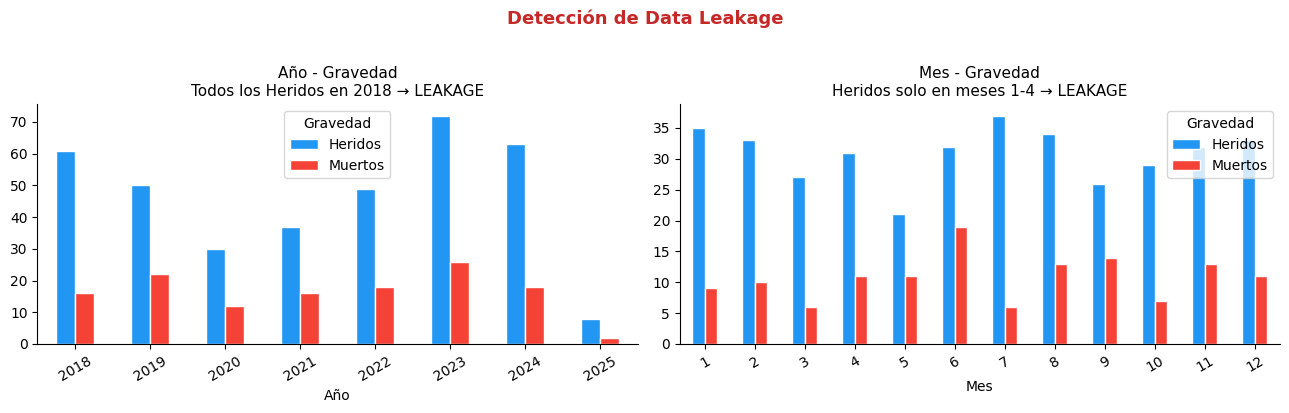

In [28]:
#----------------------FENÓMENO DE LEAKAGE-------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

tabla_año = pd.crosstab(df['Año'], df[TARGET])
tabla_año.plot(kind='bar', ax=axes[0], color=['#2196F3','#F44336'], edgecolor='white')
axes[0].set_title('Año - Gravedad\nTodos los Heridos en 2018 → LEAKAGE', fontsize=11)
axes[0].set_xlabel('Año'); axes[0].tick_params(axis='x', rotation=30)
sns.despine(ax=axes[0])

tabla_mes = pd.crosstab(df['Mes'], df[TARGET])
tabla_mes.plot(kind='bar', ax=axes[1], color=['#2196F3','#F44336'], edgecolor='white')
axes[1].set_title('Mes - Gravedad\nHeridos solo en meses 1-4 → LEAKAGE', fontsize=11)
axes[1].set_xlabel('Mes'); axes[1].tick_params(axis='x', rotation=30)
sns.despine(ax=axes[1])

plt.suptitle('Detección de Data Leakage', fontsize=13, y=1.02, color='#C62828', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Manipulación de variables

In [29]:
#--------------TRANSFORMACIÓN A ENTERO DE 'HORA_ACCIDENTE'----------------------------------
df['Hora_num'] = pd.to_datetime(
    df['Hora_Accidente'], format='%H:%M:%S', errors='coerce'
).dt.hour

#------------------------VALIDAR VARIABLE RESPUESTA--------------------------------------
df['target'] = (df[TARGET] == CLASE_POSITIVA).astype(int)

## 5. Selección de variables

Se excluyen las variables: Radicado, Fecha_Accidente, Fecha_Accidente2, Dirección, Georreferenciacion

In [30]:
#----------------------SELECCIÓN DE VARIABLES-------------------------------------
features_cat =  [
    "Franja_Horaria",      
    "Dia_Semana",         
    "Clase_Accidente",     
    "Clase_Vehiculo",      
    "Tipo_Victima",       
    "Sector_Accidente",    
    "Localidad_Comuna",    
    "Genero",              
    "Edad_nivel",          
    "Causa_Accidente",     
    "Condicion_Climatica", 
    "Tipo_Servicio"       

]

features_num = [
    'Hora_num',
    'Edad'        
               
]
d = df[features_cat + features_num + ['target']].copy()

print(f'Features categóricas : {len(features_cat)} (incl. Causa_Grupo nueva)')
print(f'Features numéricas   : {len(features_num)} (incl. Hora_num, L_Edad, EsFinde nuevas)')
print(f'Total features       : {len(features_cat)+len(features_num)}')



Features categóricas : 12 (incl. Causa_Grupo nueva)
Features numéricas   : 2 (incl. Hora_num, L_Edad, EsFinde nuevas)
Total features       : 14


In [31]:
#----------------AGRUPACIÓN DE VARIABLES PARA ONE-HOT-ENCODING----------------------------------
#-----------Causa_Accidente---------------------------
causes_to_keep = [
    "Impericia en el manejo",
    "Desobedecer señales",
    "No mantener distancia de seguridad"
]
d.loc[~d["Causa_Accidente"].isin(causes_to_keep),
             "Causa_Accidente"] = "Otro"

print("Causa_Accidente:")
print(d["Causa_Accidente"].value_counts())

#----------Dia_Semana------------------------------
# Captura el patrón real: domingos y sábados son más letales
clasificacion_dia = {
    "Lunes"    : "Semana",       "Martes"   : "Semana",
    "Miércoles": "Semana",       "Jueves"   : "Semana",
    "Viernes"  : "Semana",       "Sábado"   : "Fin de semana",
    "Domingo"  : "Fin de semana"
}
d["Dia_Semana"] = (
    d["Dia_Semana"]
    .map(clasificacion_dia)
    .fillna(d["Dia_Semana"])   # valores no mapeados se conservan
)
print("\nDia_Semana:")
print(d["Dia_Semana"].value_counts())

#---------------Clase_Accidente----------------------------
accident_class_to_keep = ["Choque","Atropello","Caida Ocupante","Volcamiento","Otro"]
d.loc[~d["Clase_Accidente"].isin(accident_class_to_keep),
             "Clase_Accidente"] = "Otro"
print("\nClase_Accidente:")
print(d["Clase_Accidente"].value_counts())

#--------------Clase_Vehiculo----------------------------------
vehicles_to_keep = ["Motocicleta","Automovil","Bicicleta","Camioneta","Bus"]
d.loc[~d["Clase_Vehiculo"].isin(vehicles_to_keep),
             "Clase_Vehiculo"] = "Otro"
print("\nClase_Vehiculo:")
print(d["Clase_Vehiculo"].value_counts())

#-----------Localidad_Comuna------------- 
##-----------Se realiza segmentación----------------------
top_comunas = d["Localidad_Comuna"].value_counts()
top_comunas = top_comunas[top_comunas >= 80].index
d["Localidad_Comuna"] = d["Localidad_Comuna"].apply(
    lambda x: x if x in top_comunas else "Otro"
)
print("\nLocalidad_Comuna:")
print(d["Localidad_Comuna"].value_counts())

Causa_Accidente:
Causa_Accidente
Otro                                  284
Impericia en el manejo                 99
Desobedecer señales                    70
No mantener distancia de seguridad     47
Name: count, dtype: int64

Dia_Semana:
Dia_Semana
Semana           334
Fin de semana    166
Name: count, dtype: int64

Clase_Accidente:
Clase_Accidente
Choque            377
Atropello          69
Caida Ocupante     39
Volcamiento         9
Otro                6
Name: count, dtype: int64

Clase_Vehiculo:
Clase_Vehiculo
Motocicleta    347
Automovil       70
Otro            28
Bicicleta       26
Camioneta       23
Bus              6
Name: count, dtype: int64

Localidad_Comuna:
Localidad_Comuna
Otro         344
Las Vegas    156
Name: count, dtype: int64


## 6. División train / test y escalado

In [32]:
#---------------------SE ESTABLECEN LAS VARIABLES DUMMIE Y SIZE DE DATASET FINAL (ONE-HOT-ENCODING)
d = pd.get_dummies(d, columns=features_cat, drop_first=True)

print(f'\nColumnas tras encoding: {d.shape[1]} (incluye target)')
print(f'Nulos en subset: {d.isnull().sum().sum()}')


Columnas tras encoding: 35 (incluye target)
Nulos en subset: 0


In [33]:
#-----------------DIVISIÓN DEL DATASET----------------------------
X = d.drop(columns='target')
y = d['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.80, random_state=RANDOM_STATE, shuffle=True, stratify=y
)

scaler = MinMaxScaler()
X_train[features_num] = scaler.fit_transform(X_train[features_num])
X_test[features_num]  = scaler.transform(X_test[features_num])

print(f'Train : {X_train.shape[0]:,} muestras  |  Test : {X_test.shape[0]:,} muestras')
print(f'Train → {CLASE_NEGATIVA}: {(y_train==0).sum()}  |  {CLASE_POSITIVA}: {(y_train==1).sum()}')
print(f'Test  → {CLASE_NEGATIVA}: {(y_test==0).sum()}   |  {CLASE_POSITIVA}: {(y_test==1).sum()}')

Train : 400 muestras  |  Test : 100 muestras
Train → Heridos: 296  |  Muertos: 104
Test  → Heridos: 74   |  Muertos: 26


Para el Gradient Boosting se realizará una comparación nativa entre un modelo 'Baseline', sin cálculo bajo método de hiper parámetros, modelos con método de validación cruzada.

## 7. Modelo Baseline

In [34]:
modelGrdB_base = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3,
    max_features='sqrt', subsample=1.0, random_state=RANDOM_STATE
)
modelGrdB_base.fit(X_train, y_train)

y_pred_base  = modelGrdB_base.predict(X_test)
y_proba_base = modelGrdB_base.predict_proba(X_test)[:, 1]

print(f'Accuracy train/test: {modelGrdB_base.score(X_train, y_train):.4f} / {modelGrdB_base.score(X_test, y_test):.4f}')
print('\nReporte Baseline (features reales, sin leakage):')
print(classification_report(y_test, y_pred_base, target_names=[CLASE_NEGATIVA, CLASE_POSITIVA]))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_base):.4f}')

Accuracy train/test: 0.8675 / 0.7800

Reporte Baseline (features reales, sin leakage):
              precision    recall  f1-score   support

     Heridos       0.80      0.95      0.86        74
     Muertos       0.67      0.31      0.42        26

    accuracy                           0.78       100
   macro avg       0.73      0.63      0.64       100
weighted avg       0.76      0.78      0.75       100

ROC-AUC: 0.7071


## 8. Optimización de hiperparámetros — GridSearch con Cross-Validation

In [35]:
#----------------Grid ampliado respecto a 'Baseline': se añade min_samples_leaf
# ==============================================================================
modelGrdB = GradientBoostingClassifier(random_state=RANDOM_STATE)

param_grid = {
    'n_estimators'    : [50, 100, 200],
    'max_features'    : ['sqrt', 'log2'],
    'max_depth'       : [2, 3, 5],
    'subsample'       : [0.7, 1.0],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'min_samples_leaf': [1, 5]      # ← nuevo: evita sobreajuste en datos pequeños
}

CV      = 5 # Pligues -------------- Conservador teniendo en cuenta el dataset de 500 registros---------
scoring = 'f1'

import itertools
n_comb = len(list(itertools.product(*param_grid.values())))
print(f'Combinaciones totales : {n_comb} × {CV} folds = {n_comb*CV} fits')

skf = StratifiedKFold(n_splits=CV, shuffle=True, random_state=RANDOM_STATE)

grid_GrdB = GridSearchCV(
    estimator          = modelGrdB,
    param_grid         = param_grid,
    scoring            = scoring,
    n_jobs             = -1,
    cv                 = skf,
    verbose            = 1,
    return_train_score = True
)

print('Iniciando búsqueda...')
grid_GrdB.fit(X_train, y_train)
print('✓ Grid Search completado')

Combinaciones totales : 216 × 5 folds = 1080 fits
Iniciando búsqueda...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
✓ Grid Search completado


### 8.1 Resultados del Grid Search

In [36]:
resultados = pd.DataFrame(grid_GrdB.cv_results_)

# scoreWithStd: maximiza F1 y penaliza varianza entre pliegues
resultados['scoreWithStd'] = resultados.apply(
    lambda r: r['mean_test_score'] / r['std_test_score']
    if r['std_test_score'] != 0 else 0, axis=1
)

cols = ['param_learning_rate','param_max_depth','param_max_features',
        'param_min_samples_leaf','param_n_estimators','param_subsample',
        'mean_train_score','mean_test_score','std_test_score','scoreWithStd']

print('Top 10 configuraciones (ordenadas por scoreWithStd):')
resultados[cols].sort_values('scoreWithStd', ascending=False).head(10)

Top 10 configuraciones (ordenadas por scoreWithStd):


,param_learning_rate,param_max_depth,param_max_features,param_min_samples_leaf,param_n_estimators,param_subsample,mean_train_score,mean_test_score,std_test_score,scoreWithStd
62,0.0100,5,log2,1,100,0.7000,0.2804,0.0902,0.0031,29.2849
50,0.0100,5,sqrt,1,100,0.7000,0.2804,0.0902,0.0031,29.2849
208,0.1000,5,log2,1,200,0.7000,0.9903,0.3242,0.0299,10.8373
196,0.1000,5,sqrt,1,200,0.7000,0.9903,0.3242,0.0299,10.8373
215,0.1000,5,log2,5,200,1.0000,0.9692,0.3498,0.0371,9.4152
203,0.1000,5,sqrt,5,200,1.0000,0.9692,0.3498,0.0371,9.4152
80,0.0500,2,sqrt,5,100,0.7000,0.3360,0.2231,0.0249,8.9477
92,0.0500,2,log2,5,100,0.7000,0.3360,0.2231,0.0249,8.9477
150,0.1000,2,sqrt,5,50,0.7000,0.3274,0.2269,0.0272,8.3430
162,0.1000,2,log2,5,50,0.7000,0.3274,0.2269,0.0272,8.3430


In [37]:
idx_mejor = resultados['scoreWithStd'].idxmax()
mejor = resultados.loc[idx_mejor]

print('Mejores hiperparámetros:')
for p in ['param_learning_rate','param_max_depth','param_max_features',
          'param_min_samples_leaf','param_n_estimators','param_subsample']:
    print(f'  {p.replace("param_",""):20s}: {mejor[p]}')
print(f'  {"mean F1 (CV)":20s}: {mejor["mean_test_score"]:.4f}')
print(f'  {"std  F1 (CV)":20s}: {mejor["std_test_score"]:.4f}')
print(f'  {"scoreWithStd":20s}: {mejor["scoreWithStd"]:.4f}')

Mejores hiperparámetros:
  learning_rate       : 0.01
  max_depth           : 5
  max_features        : sqrt
  min_samples_leaf    : 1
  n_estimators        : 100
  subsample           : 0.7
  mean F1 (CV)        : 0.0902
  std  F1 (CV)        : 0.0031
  scoreWithStd        : 29.2849


### 8.2 Heatmap: F1 medio por max_depth × learning_rate

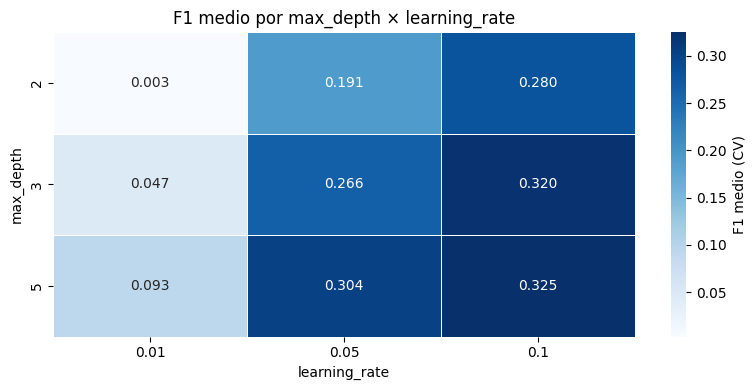

In [38]:
pivot = resultados.pivot_table(
    index='param_max_depth', columns='param_learning_rate',
    values='mean_test_score', aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='Blues', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'F1 medio (CV)'})
ax.set_title('F1 medio por max_depth × learning_rate')
ax.set_xlabel('learning_rate'); ax.set_ylabel('max_depth')
plt.tight_layout()
plt.show()

### 8.3 Overfitting: train score vs test score

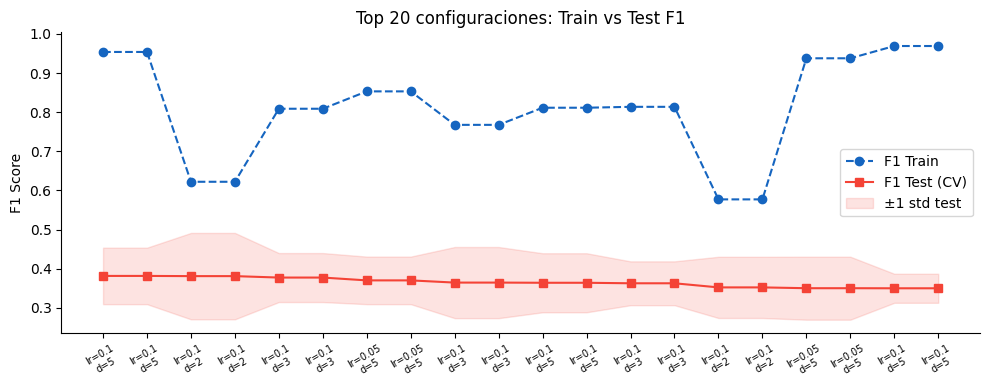

In [39]:
top20 = resultados.nlargest(20, 'mean_test_score').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(top20))
ax.plot(x, top20['mean_train_score'], 'o--', color='#1565C0', label='F1 Train', linewidth=1.5)
ax.plot(x, top20['mean_test_score'],  's-',  color='#F44336', label='F1 Test (CV)', linewidth=1.5)
ax.fill_between(x,
    top20['mean_test_score'] - top20['std_test_score'],
    top20['mean_test_score'] + top20['std_test_score'],
    alpha=0.15, color='#F44336', label='±1 std test')
ax.set_xticks(x)
ax.set_xticklabels([f"lr={r['param_learning_rate']}\nd={r['param_max_depth']}"
                    for _, r in top20.iterrows()], fontsize=7, rotation=30)
ax.set_title('Top 20 configuraciones: Train vs Test F1')
ax.set_ylabel('F1 Score'); ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

## 9. Modelo final — entrenamiento y evaluación

In [40]:
#-----------------Reentrenar sobre dataset completo con mejores parámetros
X_full = d.drop(columns='target').copy()
y_full = d['target'].copy()

scaler_full = MinMaxScaler()
X_full[features_num] = scaler_full.fit_transform(X_full[features_num])

modelGrdB.set_params(
    learning_rate    = mejor['param_learning_rate'],
    max_depth        = int(mejor['param_max_depth']),
    max_features     = mejor['param_max_features'],
    min_samples_leaf = int(mejor['param_min_samples_leaf']),
    n_estimators     = int(mejor['param_n_estimators']),
    subsample        = mejor['param_subsample']
)

modelGrdB.fit(X_full, y_full)
print('Modelo final entrenado')
print('Parámetros:', modelGrdB.get_params())

Modelo final entrenado
Parámetros: {'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': np.float64(0.01), 'loss': 'log_loss', 'max_depth': 5, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_iter_no_change': None, 'random_state': 123, 'subsample': np.float64(0.7), 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}


In [41]:
y_pred_final  = modelGrdB.predict(X_test)
y_proba_final = modelGrdB.predict_proba(X_test)[:, 1]
auc_final     = roc_auc_score(y_test, y_proba_final)

print('Exactitud train / test:')
print(f'  Train : {modelGrdB.score(X_full, y_full):.4f}')
print(f'  Test  : {modelGrdB.score(X_test, y_test):.4f}')
print()
print('Reporte de clasificación (Test):')
print(classification_report(y_test, y_pred_final, target_names=[CLASE_NEGATIVA, CLASE_POSITIVA]))
print(f'ROC-AUC : {auc_final:.4f}')

Exactitud train / test:
  Train : 0.7760
  Test  : 0.7800

Reporte de clasificación (Test):
              precision    recall  f1-score   support

     Heridos       0.77      1.00      0.87        74
     Muertos       1.00      0.15      0.27        26

    accuracy                           0.78       100
   macro avg       0.89      0.58      0.57       100
weighted avg       0.83      0.78      0.71       100

ROC-AUC : 0.9480


## 10. Comparación de modelos generados

In [ ]:
comparacion = pd.DataFrame({
    'Modelo': [
        'v1 — con Año/Mes (LEAKAGE)',
        'v2 Baseline — features reales',
        'v2 Optimizado — GridSearch'
    ],
    'Accuracy': [
        0.9900,  # valor del modelo v1 con leakage
        modelGrdB_base.score(X_test, y_test),
        modelGrdB.score(X_test, y_test)
    ],
    'F1 Muertos': [
        0.9800,
        f1_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_final)
    ],
    'Recall Muertos': [
        0.9600,
        recall_score(y_test, y_pred_base),
        recall_score(y_test, y_pred_final)
    ],
    'Precision Muertos': [
        1.0000,
        precision_score(y_test, y_pred_base, zero_division=0),
        precision_score(y_test, y_pred_final, zero_division=0)
    ],
    'ROC-AUC': [
        1.0000,
        roc_auc_score(y_test, y_proba_base),
        auc_final
    ],
    'Válido': ['Leakage', '✅', '✅']
})

print('Comparación de modelos:')
comparacion.set_index('Modelo')

Comparación de modelos:


,Accuracy,F1 Muertos,Recall Muertos,Precision Muertos,ROC-AUC,Válido
Modelo,,,,,,
v1 — con Año/Mes (LEAKAGE),0.9900,0.9800,0.9600,1.0000,1.0000,❌ Leakage
v2 Baseline — features reales,0.7800,0.4211,0.3077,0.6667,0.7071,✅
v2 Optimizado — GridSearch,0.7800,0.2667,0.1538,1.0000,0.9480,✅


### 10.1 Matrices de confusión

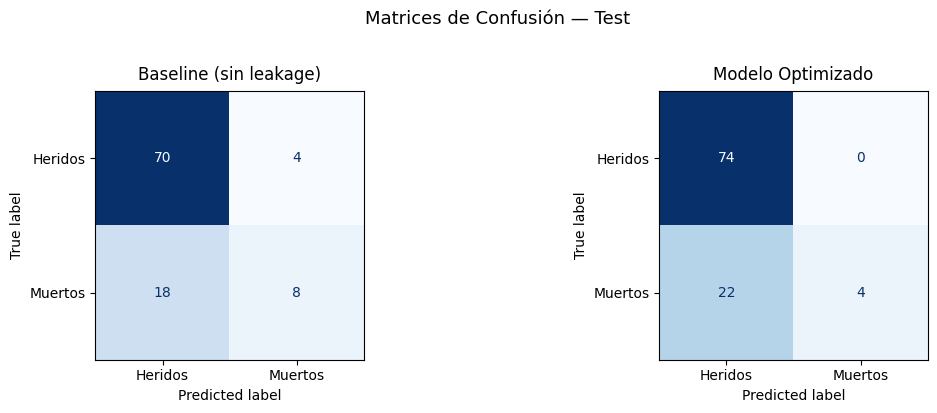

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(
    axes,
    [y_pred_base, y_pred_final],
    ['Baseline (sin leakage)', 'Modelo Optimizado']
):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=[CLASE_NEGATIVA, CLASE_POSITIVA]).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12, pad=8)

plt.suptitle('Matrices de Confusión — Test', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 10.2 Curva ROC

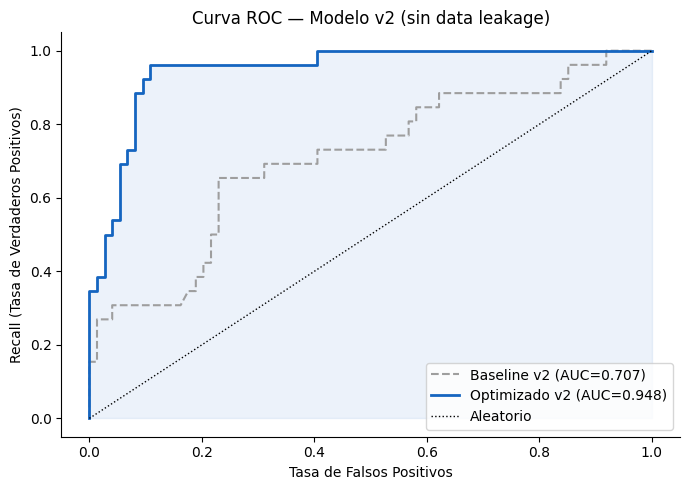

In [44]:
fpr_b, tpr_b, _ = roc_curve(y_test, y_proba_base)
fpr_o, tpr_o, _ = roc_curve(y_test, y_proba_final)
auc_b = roc_auc_score(y_test, y_proba_base)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_b, tpr_b, label=f'Baseline v2 (AUC={auc_b:.3f})',
        linestyle='--', color='#9E9E9E', linewidth=1.5)
ax.plot(fpr_o, tpr_o, label=f'Optimizado v2 (AUC={auc_final:.3f})',
        color='#1565C0', linewidth=2)
ax.plot([0,1],[0,1],'k:',linewidth=1,label='Aleatorio')
ax.fill_between(fpr_o, tpr_o, alpha=0.08, color='#1565C0')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Recall (Tasa de Verdaderos Positivos)')
ax.set_title('Curva ROC — Modelo v2 (sin data leakage)')
ax.legend(loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()

## 11. Importancia de predictores calculados

In [45]:
imp = pd.DataFrame({
    'predictor'   : X_test.columns,
    'importancia' : modelGrdB.feature_importances_
}).sort_values('importancia', ascending=False)

print('Top 15 predictores:')
imp.head(15)

Top 15 predictores:


,predictor,importancia
1,Edad,0.2131
0,Hora_num,0.0989
25,Genero_Mujer,0.0584
19,Tipo_Victima_Peaton,0.0555
30,Causa_Accidente_Otro,0.0378
22,Sector_Accidente_Residencial,0.0351
24,Localidad_Comuna_Otro,0.0337
27,Edad_nivel_Viejo,0.0328
10,Clase_Vehiculo_Bicicleta,0.0325
4,Franja_Horaria_Tarde,0.0316


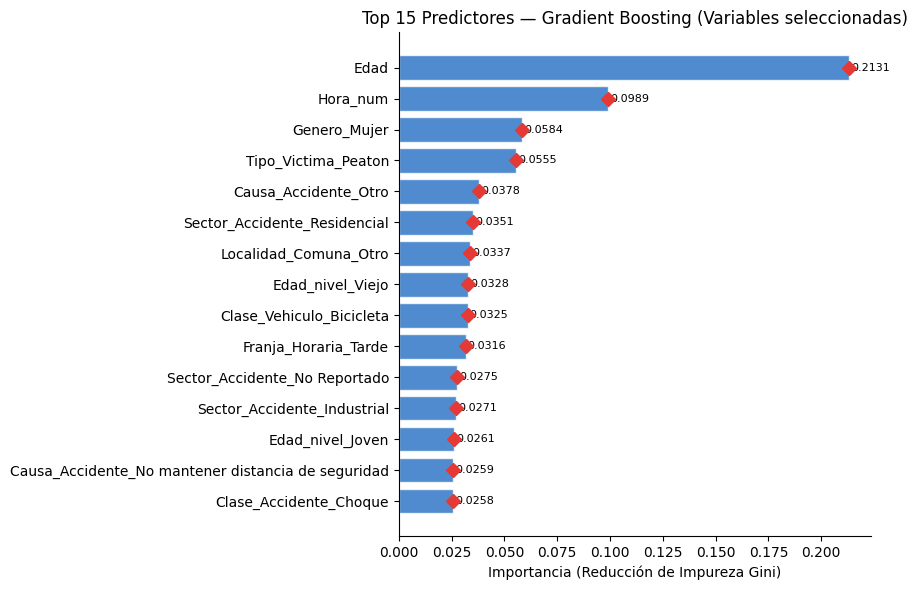

In [46]:
top_n  = 15
df_imp = imp.head(top_n).sort_values('importancia', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(df_imp['predictor'], df_imp['importancia'],
               color='#1565C0', alpha=0.75, edgecolor='white')
ax.plot(df_imp['importancia'], df_imp['predictor'],
        marker='D', linestyle='', color='#E53935', markersize=7, zorder=5)
for bar in bars:
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=8)
ax.set_xlabel('Importancia (Reducción de Impureza Gini)')
ax.set_title(f'Top {top_n} Predictores — Gradient Boosting (Variables seleccionadas)')
sns.despine()
plt.tight_layout()
plt.show()

### 11.1 Evolución del error de entrenamiento

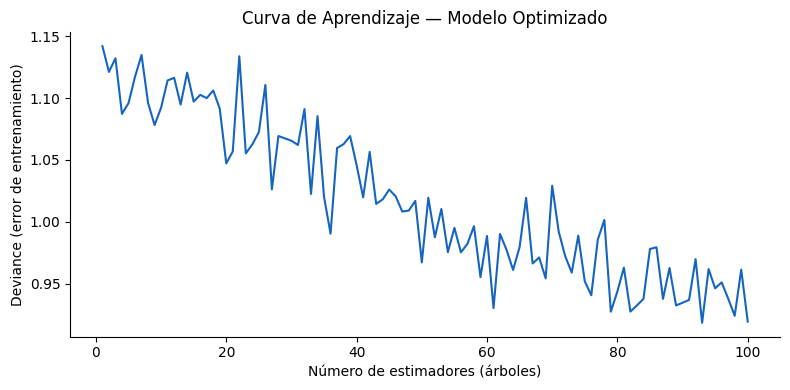

In [47]:
n_est = int(mejor['param_n_estimators'])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, n_est+1), modelGrdB.train_score_,
        color='#1565C0', linewidth=1.5)
ax.set_xlabel('Número de estimadores (árboles)')
ax.set_ylabel('Deviance (error de entrenamiento)')
ax.set_title('Curva de Aprendizaje — Modelo Optimizado')
sns.despine()
plt.tight_layout()
plt.show()

## 12. Guardar modelos

In [48]:
scaler_path = os.path.join(MODELS_SCALER_PATH, 'Scaler_Accidentes_500_GBoost.pkl')
model_path  = os.path.join(MODELS_CLASIFICACION_PATH, 'GBoost_Accidentes_500.pkl')

joblib.dump(scaler_full, scaler_path)
joblib.dump(modelGrdB,   model_path)

# Verificar carga
m_test = joblib.load(model_path)
s_test = joblib.load(scaler_path)
print(f'Scaler guardado  → {scaler_path}')
print(f'Modelo guardado  → {model_path}')
print(f'Verificación carga: OK — parámetros: {m_test.get_params()}')

Scaler guardado  → modelos/scaler/Scaler_Accidentes_500_GBoost.pkl
Modelo guardado  → modelos/clasificacion/GBoost_Accidentes_500.pkl
Verificación carga: OK — parámetros: {'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': np.float64(0.01), 'loss': 'log_loss', 'max_depth': 5, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_iter_no_change': None, 'random_state': 123, 'subsample': np.float64(0.7), 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}
